# Bike sharing data: understand the data

Run each cell from top to bottom.

In [18]:
from pathlib import Path
import pandas as pd

candidate_dirs = [Path('../data'), Path('data')]
data_dir = next((path for path in candidate_dirs if path.exists()), None)
if data_dir is None:
    raise FileNotFoundError('Cannot find the data folder.')

csv_files = list(data_dir.glob('*.csv'))
[file.name for file in csv_files]

['day.csv', 'hour.csv']

In [19]:
if not csv_files:
    raise FileNotFoundError('No CSV files found in the data folder.')

data_file = next((file for file in csv_files if file.name.lower() == 'day.csv'), csv_files[0])
df = pd.read_csv(data_file)
print(f'Reading: {data_file.name}')
df.head()

Reading: day.csv


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [20]:
print(f'Data shape: {df.shape}')
df.info()

Data shape: (731, 16)
<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 91.5 KB


In [21]:
df.isnull().sum().sort_values(ascending=False)

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

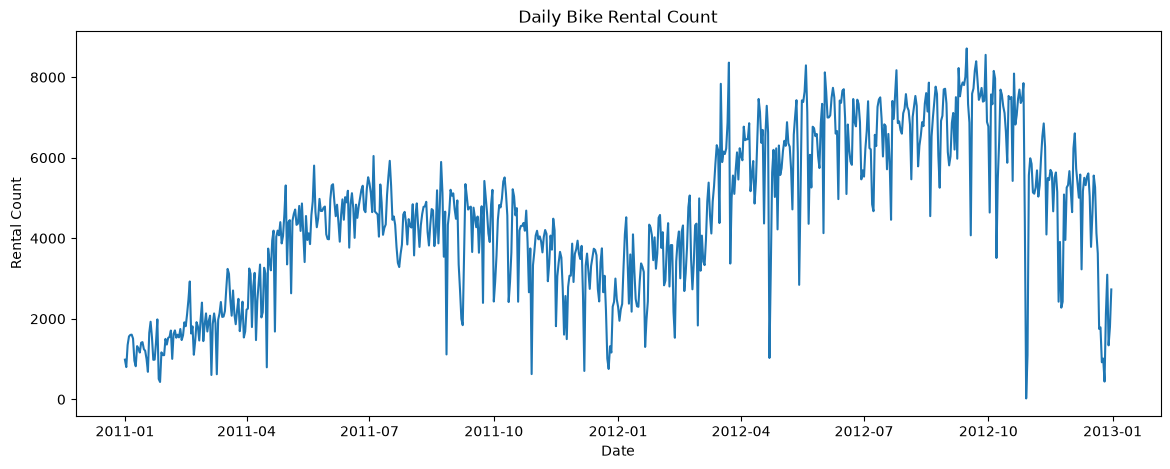

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

df["dteday"] = pd.to_datetime(df["dteday"])

plt.figure(figsize=(14, 5))
sns.lineplot(data=df, x="dteday", y="cnt")

plt.title("Daily Bike Rental Count")
plt.xlabel("Date")
plt.ylabel("Rental Count")
plt.show()

租赁量总体是上升、下降，还是没有明显趋势？
总体时承上升趋势
哪些时间段波动较大？
2011-01到2011-07，2012-01到2012-10以及2012-10后的一小段时间急剧下降
是否有明显的季节性，例如夏天更多、冬天更少？
对的夏天会更多冬天会更少

In [23]:
workday_mean = (
    df.groupby("workingday")["cnt"]
    .mean()
    .rename({0: "Non-working day", 1: "Working day"})
)

workday_mean


workingday
Non-working day    4330.168831
Working day        4584.820000
Name: cnt, dtype: float64

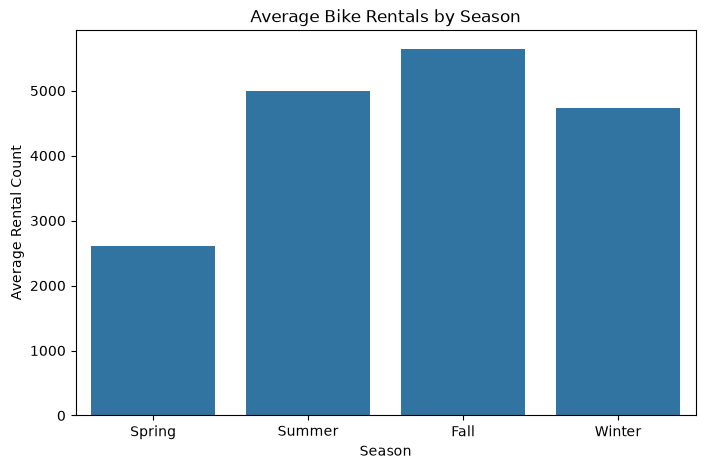

season_name
Spring    2604.132597
Summer    4992.331522
Fall      5644.303191
Winter    4728.162921
Name: cnt, dtype: float64

In [24]:
season_labels = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

season_mean = (
    df.assign(season_name=df["season"].map(season_labels))
    .groupby("season_name")["cnt"]
    .mean()
    .reindex(["Spring", "Summer", "Fall", "Winter"])
)

plt.figure(figsize=(8, 5))
sns.barplot(x=season_mean.index, y=season_mean.values)

plt.title("Average Bike Rentals by Season")
plt.xlabel("Season")
plt.ylabel("Average Rental Count")
plt.show()

season_mean


哪个季节平均租赁量最高，哪个最低？
秋天最高春天最低

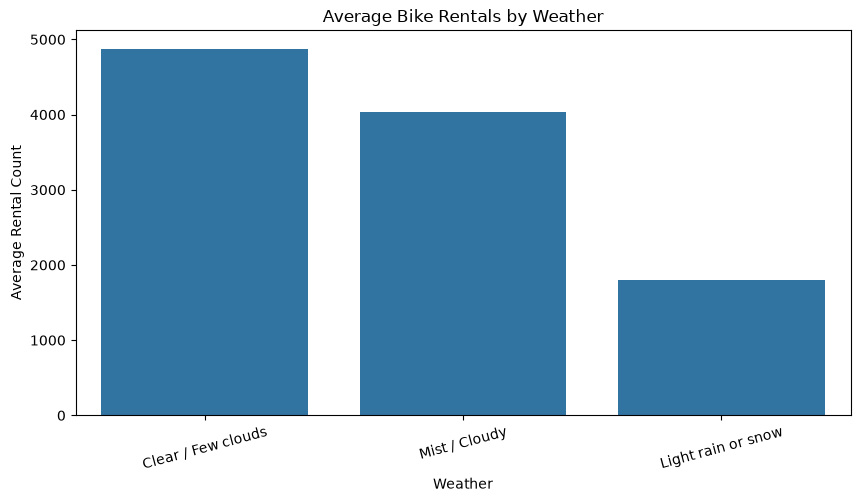

weather_name
Clear / Few clouds    4876.786177
Mist / Cloudy         4035.862348
Light rain or snow    1803.285714
Name: cnt, dtype: float64

In [25]:
weather_labels = {
    1: "Clear / Few clouds",
    2: "Mist / Cloudy",
    3: "Light rain or snow",
    4: "Heavy rain or snow"
}

weather_mean = (
    df.assign(weather_name=df["weathersit"].map(weather_labels))
    .groupby("weather_name")["cnt"]
    .mean()
    .reindex(weather_labels.values())
    .dropna()
)

plt.figure(figsize=(10, 5))
sns.barplot(x=weather_mean.index, y=weather_mean.values)

plt.title("Average Bike Rentals by Weather")
plt.xlabel("Weather")
plt.ylabel("Average Rental Count")
plt.xticks(rotation=15)
plt.show()

weather_mean

晴朗或少云天气下的平均租赁量最高；多云、薄雾天气居中；轻度雨雪天气最低。天气越差，用户骑行意愿通常越低。

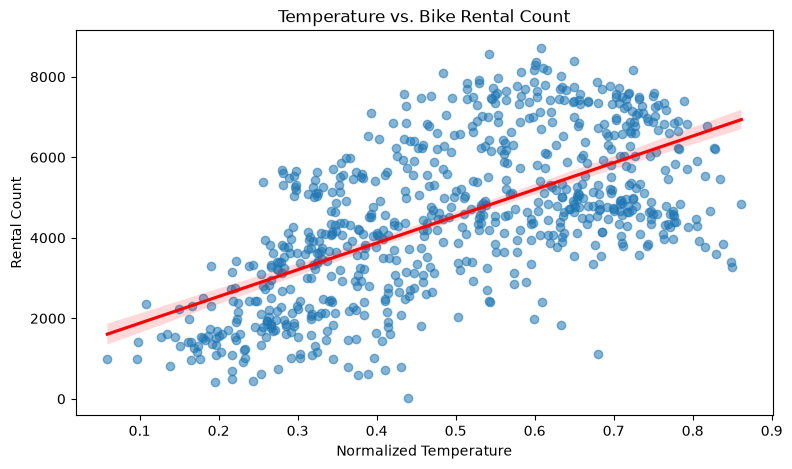

,temp,cnt
temp,1.000000,0.627494
cnt,0.627494,1.000000


In [26]:
plt.figure(figsize=(9, 5))
sns.regplot(
    data=df,
    x="temp",
    y="cnt",
    scatter_kws={"alpha": 0.55},
    line_kws={"color": "red"}
)

plt.title("Temperature vs. Bike Rental Count")
plt.xlabel("Normalized Temperature")
plt.ylabel("Rental Count")
plt.show()

df[["temp", "cnt"]].corr()

温度升高时，租赁量总体倾向于增加；但点分布仍然比较分散，说明温度不是唯一因素

# 共享单车租赁数据分析小结

## 1. 分析目标

本项目使用共享单车日租赁数据，分析租赁量随时间、工作日、季节、天气和温度的变化规律。

## 2. 数据概况

- 数据文件：`day.csv`
- 数据规模：731 条日级记录，16 个字段
- 时间范围：2011 年至 2012 年
- 目标指标：`cnt`，表示当天共享单车总租赁量
- 缺失值：各字段均未发现缺失值

## 3. 主要发现

### 3.1 时间趋势

日租赁量存在明显的季节性波动。整体来看，2012 年的租赁量普遍高于 2011 年，但每年冬季附近都会出现明显回落。

### 3.2 工作日影响

工作日的平均租赁量约为 4585 次，非工作日约为 4330 次。工作日平均租赁量略高，约高 5.9%。

### 3.3 季节影响

秋季的平均租赁量最高，春季最低，说明租赁需求具有明显的季节性差异。

### 3.4 天气影响

晴朗或少云天气下的平均租赁量最高；多云、薄雾天气居中；轻度雨雪天气最低。天气状况变差时，用户的骑行需求通常会下降。

### 3.5 温度影响

温度与日租赁量的相关系数约为 0.63，呈中等偏强的正相关。温度较高时，租赁量通常更多，但天气、季节和工作日等因素也会共同影响租赁量。

## 4. 结论与后续方向

共享单车租赁量受到时间趋势、季节、天气、温度和工作日等多因素共同影响。后续可以使用这些因素建立预测模型，预测未来某一天的共享单车租赁需求。

In [27]:
import sys
import sklearn

print(sys.executable)
print(sklearn.__version__)

c:\Users\刘珞宁\Documents\bike-sharing-analysis\.venv\Scripts\python.exe
1.9.0


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 用于预测租赁量的输入特征
features = [
    "season", "yr", "mnth", "holiday", "weekday",
    "workingday", "weathersit", "temp", "atemp",
    "hum", "windspeed"
]

X = df[features]
y = df["cnt"]

# 前 80% 日期训练，后 20% 日期测试
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# 训练模型
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# 测试集预测与评估
y_pred = linear_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"训练集记录数：{len(X_train)}")
print(f"测试集记录数：{len(X_test)}")
print(f"平均绝对误差 MAE：{mae:.2f}")
print(f"决定系数 R²：{r2:.3f}")

训练集记录数：584
测试集记录数：147
平均绝对误差 MAE：863.86
决定系数 R²：0.613


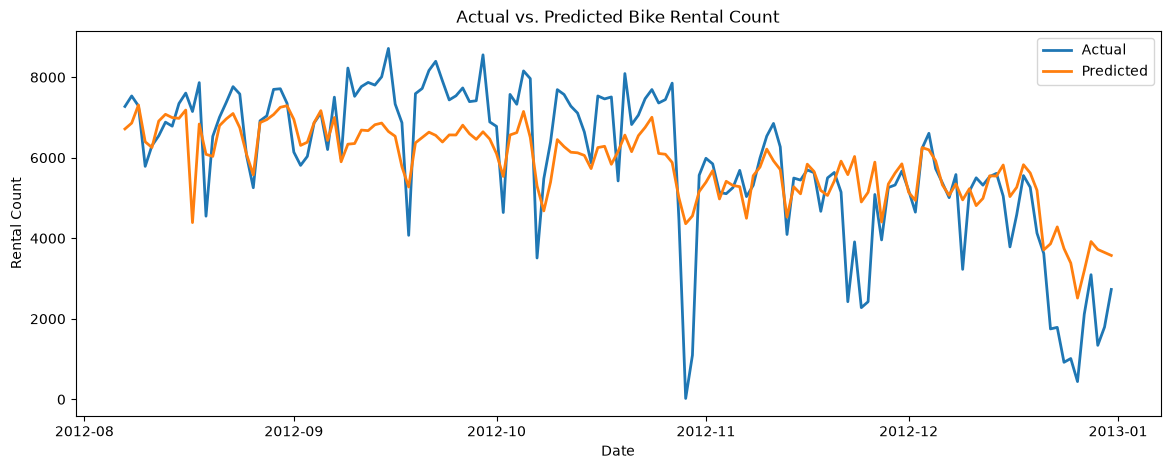

In [29]:
test_dates = df["dteday"].iloc[split_index:]

plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_test, label="Actual", linewidth=2)
plt.plot(test_dates, y_pred, label="Predicted", linewidth=2)

plt.title("Actual vs. Predicted Bike Rental Count")
plt.xlabel("Date")
plt.ylabel("Rental Count")
plt.legend()
plt.show()

天气、温度与租赁量的关系不是简单直线；
某些变量会相互影响，例如“低温 + 雨雪”带来的下降比单独低温更明显；
节假日、突发天气、运营策略等信息不在当前数据中；
线性回归的预测通常更平滑，难以拟合突然的高峰和低谷。

In [30]:
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

rf_pred = random_forest.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print(f"线性回归 MAE：{mae:.2f}")
print(f"随机森林 MAE：{rf_mae:.2f}")
print()
print(f"线性回归 R²：{r2:.3f}")
print(f"随机森林 R²：{rf_r2:.3f}")

线性回归 MAE：863.86
随机森林 MAE：910.29

线性回归 R²：0.613
随机森林 R²：0.648


如果关注“普通一天平均会预测错多少”，线性回归更好，因为它的 MAE 少约 46.43 次。
如果关注“模型能解释多少总体波动、是否更能处理大幅变化”，随机森林更好，因为 R² 更高。
这不是矛盾：随机森林可能减少了少数日期的大误差，但让更多普通日期的误差略微变大。

In [31]:
from sklearn.metrics import root_mean_squared_error

lr_rmse = root_mean_squared_error(y_test, y_pred)
rf_rmse = root_mean_squared_error(y_test, rf_pred)

print(f"线性回归 RMSE：{lr_rmse:.2f}")
print(f"随机森林 RMSE：{rf_rmse:.2f}")

线性回归 RMSE：1166.02
随机森林 RMSE：1112.20


随机森林更擅长减少“大错”，因此 RMSE 更低、R² 更高；线性回归在普通日期的平均绝对误差略小。
在这个项目中，可以把随机森林作为主模型，因为共享单车调度通常更怕租赁需求的大幅误判。线性回归保留为基线模型，用来证明随机森林带来的改进与取舍。

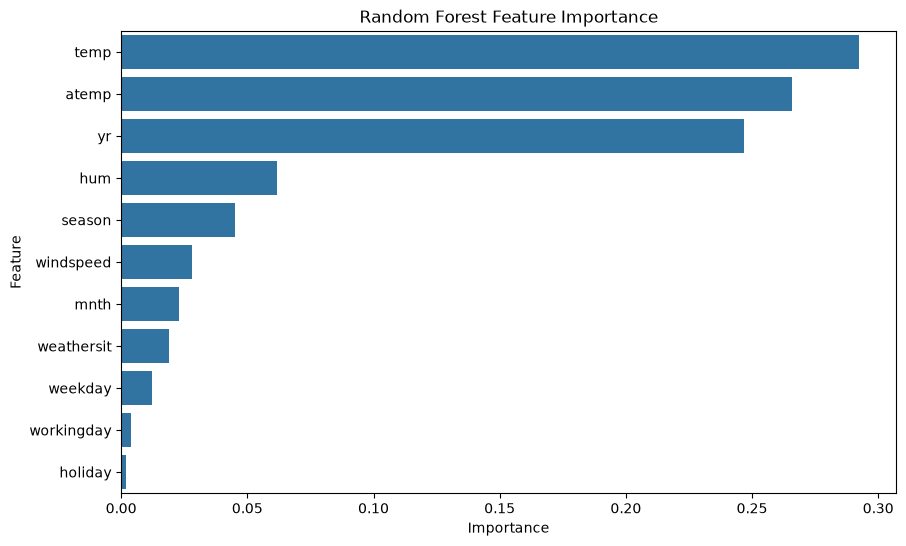

,feature,importance
7,temp,0.292488
8,atemp,0.266006
1,yr,0.246798
9,hum,0.061827
0,season,0.045091
10,windspeed,0.028062
2,mnth,0.022757
6,weathersit,0.018772
4,weekday,0.012280
5,workingday,0.003838


In [32]:
importance_df = (
    pd.DataFrame({
        "feature": features,
        "importance": random_forest.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="importance", y="feature")

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

importance_df

## 模型特征重要性

随机森林模型显示，温度（temp）、体感温度（atemp）和年份（yr）是预测共享单车租赁量最重要的三个特征。

这说明用户骑行需求主要受到舒适度和长期用户规模增长的影响。需要注意的是，温度与体感温度高度相关，因此两者的重要性存在重叠，不能直接视为相互独立的因果影响。

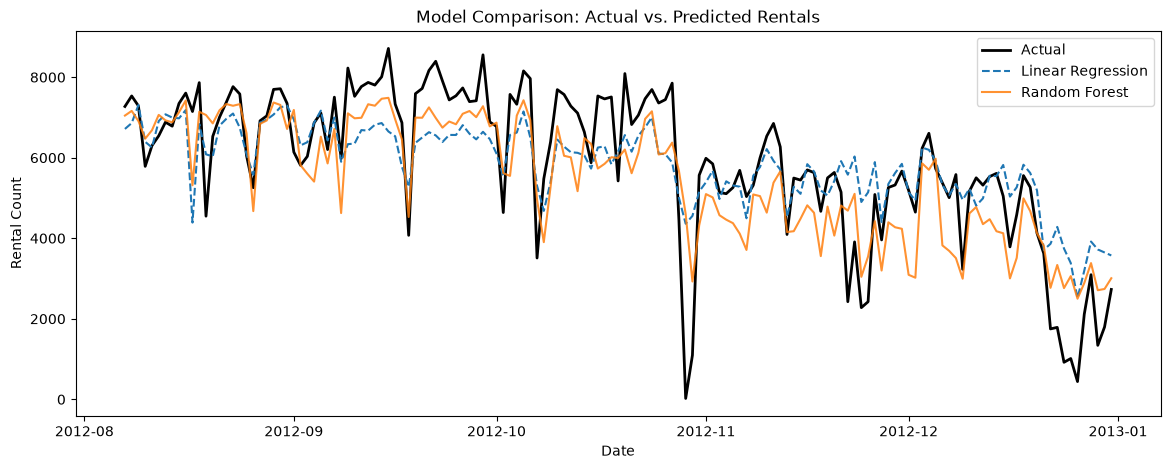

In [33]:
plt.figure(figsize=(14, 5))

plt.plot(test_dates, y_test, label="Actual", color="black", linewidth=2)
plt.plot(test_dates, y_pred, label="Linear Regression", linestyle="--")
plt.plot(test_dates, rf_pred, label="Random Forest", alpha=0.85)

plt.title("Model Comparison: Actual vs. Predicted Rentals")
plt.xlabel("Date")
plt.ylabel("Rental Count")
plt.legend()
plt.show()

随机森林在 R² 和 RMSE 指标上优于线性回归，说明其更能捕捉共享单车租赁量的复杂变化，并减少较大的预测误差。因此，本项目选择随机森林作为主预测模型。线性回归在 MAE 指标上略优，说明其对普通日期的平均预测误差更小

In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

time_cv = TimeSeriesSplit(n_splits=4)

param_distributions = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 8, 12, 16],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [1.0, "sqrt", 0.8]
}

search = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=1
    ),
    param_distributions=param_distributions,
    n_iter=8,
    scoring="neg_mean_absolute_error",
    cv=time_cv,
    random_state=42,
    n_jobs=1,
    verbose=0
)

search.fit(X_train, y_train)

best_rf = search.best_estimator_
best_rf_pred = best_rf.predict(X_test)

best_rf_mae = mean_absolute_error(y_test, best_rf_pred)
best_rf_rmse = root_mean_squared_error(y_test, best_rf_pred)
best_rf_r2 = r2_score(y_test, best_rf_pred)

print("最佳参数：")
print(search.best_params_)
print()
print(f"优化后随机森林 MAE：{best_rf_mae:.2f}")
print(f"优化后随机森林 RMSE：{best_rf_rmse:.2f}")
print(f"优化后随机森林 R²：{best_rf_r2:.3f}")

最佳参数：
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': 12}

优化后随机森林 MAE：891.26
优化后随机森林 RMSE：1080.20
优化后随机森林 R²：0.668


## 模型优化结果

通过时间序列交叉验证对随机森林进行参数优化后，模型取得 MAE 为 891.26、RMSE 为 1080.20、R² 为 0.668 的测试集表现。

与默认随机森林相比，优化后的模型在三项指标上均有改进。虽然线性回归的 MAE 更低，但优化后的随机森林具有更低的 RMSE 和更高的 R²，说明它更擅长捕捉复杂的租赁量波动并减少较大的预测偏差。

因此，本项目将优化后的随机森林作为主预测模型。

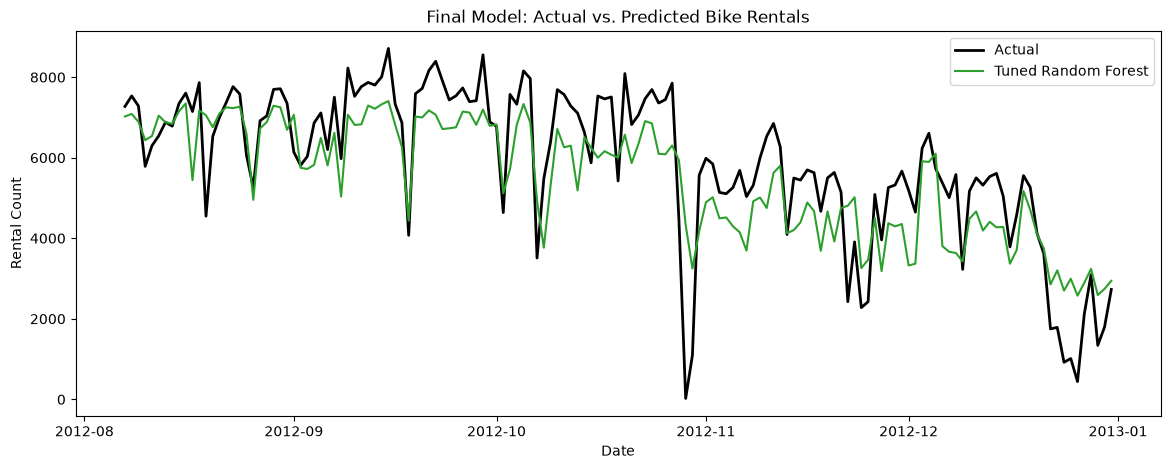

In [37]:
plt.figure(figsize=(14, 5))

plt.plot(test_dates, y_test, label="Actual", color="black", linewidth=2)
plt.plot(test_dates, best_rf_pred, label="Tuned Random Forest", color="tab:green")

plt.title("Final Model: Actual vs. Predicted Bike Rentals")
plt.xlabel("Date")
plt.ylabel("Rental Count")
plt.legend()
plt.show()

In [38]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Default Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        mae,
        rf_mae,
        best_rf_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        best_rf_rmse
    ],
    "R²": [
        r2,
        rf_r2,
        best_rf_r2
    ]
})

model_results

,Model,MAE,RMSE,R²
0,Linear Regression,863.861540,1166.020335,0.613112
1,Default Random Forest,910.289637,1112.199323,0.648003
2,Tuned Random Forest,891.255705,1080.202404,0.667965


# 项目最终结论

本项目基于共享单车日租赁数据，完成了从数据理解、探索性分析到机器学习预测的完整流程。

探索性分析发现，租赁量受到季节、天气、温度、工作日和年份等因素共同影响。其中，温度、体感温度和年份是随机森林模型中最重要的特征。

模型对比显示，优化后的随机森林取得最高的 R² 和最低的 RMSE，说明它更能捕捉租赁量的整体波动和较大的需求变化。因此，本项目选择优化后的随机森林作为主模型。

模型仍存在局限：数据未包含节假日活动、突发天气、车辆供给和区域差异等信息，因此在部分日期仍可能出现较大预测误差。